# Laboratorio 6 — Análisis de Redes Sociales en YouTube
## Notebook 2 de 4: Análisis exploratorio

Este notebook resuelve el **Ejercicio 3** del laboratorio.

Se parte de los archivos limpios producidos por el Notebook 1 y se describe el conjunto: cuántos
videos, canales, comentarios y autores hay, cómo se reparte la participación, qué se dice en los
comentarios y si la visibilidad de un video coincide con la participación que recibe.

| Sección | Contenido |
| --- | --- |
| 3.1 | Descripción de los elementos mínimos |
| 3.2 | Concentración de la participación |
| 3.3 | Popularidad frente a participación |
| 3.4 | Nube de palabras |
| 3.5 | Respuestas a las preguntas obligatorias |
| 3.6 | Preguntas adicionales |

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from wordcloud import WordCloud

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import cargar, set_estilo

set_estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

videos = cargar("videos_limpio")
comentarios = cargar("comentarios_limpio")
cv = cargar("comentarios_videos")

print("videos            ->", videos.shape)
print("comentarios       ->", comentarios.shape)
print("comentarios+videos->", cv.shape)

videos            -> (293, 25)
comentarios       -> (406, 23)
comentarios+videos-> (406, 44)


## 3.1 Descripción de los elementos mínimos

### Conteos base

In [2]:
conteos = pd.Series({
    "videos en el catálogo": videos["video_id"].nunique(),
    "canales que publican esos videos": videos["channel_id"].nunique(),
    "comentarios recolectados": comentarios["comment_id"].nunique(),
    "autores distintos de comentarios": comentarios["author_channel_id"].nunique(),
    "videos con al menos un comentario": cv["video_id"].nunique(),
    "canales con al menos un comentario": cv["channel_id"].nunique(),
}, name="total")
conteos.to_frame()

,total
videos en el catálogo,293
canales que publican esos videos,97
comentarios recolectados,406
autores distintos de comentarios,332
videos con al menos un comentario,19
canales con al menos un comentario,8


El conjunto tiene dos escalas muy distintas. El **catálogo** abarca 293 videos de 97 canales,
pero la **muestra de comentarios** solo toca 19 videos de 8 canales. Todo lo que se diga sobre
participación se refiere a esa segunda escala, mucho más pequeña.

### Videos por canal

Videos por canal
count    97.00
mean      3.02
std       5.14
min       1.00
50%       1.00
75%       2.00
90%       7.40
max      32.00

Canales con un solo video: 65 (67.0% de los canales)


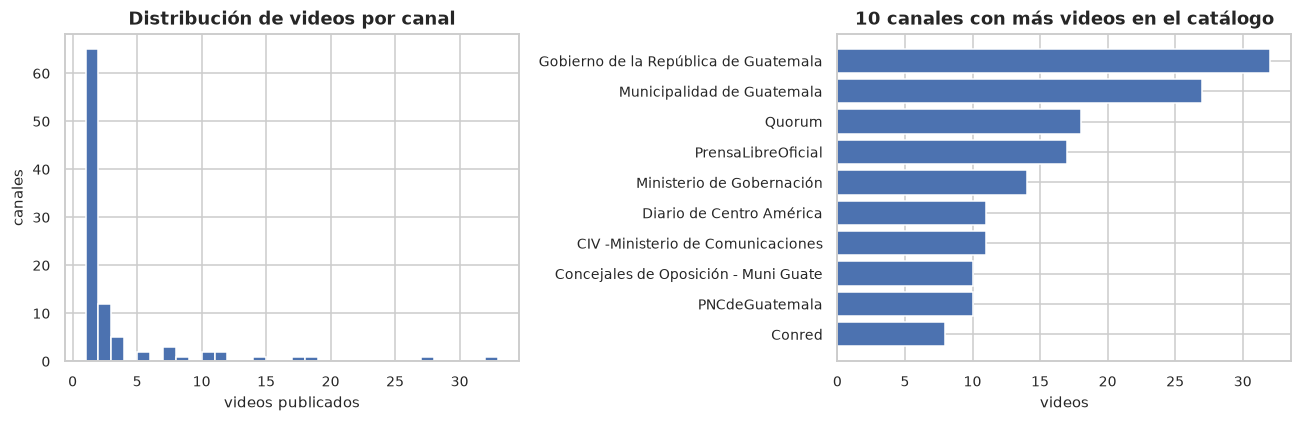

In [3]:
videos_por_canal = videos.groupby("channel_id").size()

print("Videos por canal")
print(videos_por_canal.describe([0.5, 0.75, 0.9]).round(2).to_string())
print("\nCanales con un solo video:", int((videos_por_canal == 1).sum()),
      f"({(videos_por_canal == 1).mean():.1%} de los canales)")

etiqueta_canal = videos.groupby("channel_id")["channel_name"].first()
top_canales = videos_por_canal.sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(videos_por_canal, bins=range(1, videos_por_canal.max() + 2), color="#4C72B0")
axes[0].set_title("Distribución de videos por canal")
axes[0].set_xlabel("videos publicados")
axes[0].set_ylabel("canales")

axes[1].barh(etiqueta_canal[top_canales.index][::-1], top_canales.values[::-1], color="#4C72B0")
axes[1].set_title("10 canales con más videos en el catálogo")
axes[1].set_xlabel("videos")
plt.tight_layout()
plt.show()

La mayoría de los canales aparece una sola vez: **65 de los 97 canales (67%) tienen un único
video** en el catálogo, y la mediana es de 1 video por canal. Al mismo tiempo, el canal más
presente aporta 32 videos. Es la primera señal de una distribución muy desigual, en la que la
media (3.02) no describe a un canal típico.

### Comentarios y autores únicos por video

In [4]:
por_video = cv.groupby("video_id").agg(
    comentarios=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    vistas=("view_count", "first"),
    canal=("channel_name", "first"),
    titulo=("title", "first"),
    categoria=("category", "first"),
).sort_values("comentarios", ascending=False)
por_video["com_por_autor"] = (por_video["comentarios"] / por_video["autores"]).round(2)

print("Comentarios por video (solo los 19 videos con comentarios)")
print(por_video["comentarios"].describe().round(2).to_string())
print("\nAutores únicos por video")
print(por_video["autores"].describe().round(2).to_string())

por_video[["canal", "comentarios", "autores", "com_por_autor", "vistas", "categoria"]].head(19)

Comentarios por video (solo los 19 videos con comentarios)
count     19.00
mean      21.37
std       36.82
min        1.00
25%        2.50
50%        7.00
75%       25.00
max      161.00

Autores únicos por video
count     19.00
mean      18.05
std       29.46
min        1.00
25%        2.50
50%        7.00
75%       18.50
max      128.00


,canal,comentarios,autores,com_por_autor,vistas,categoria
video_id,,,,,,
n8iP75gIpmw,Quorum,161,128,1.26,11775,News & Politics
j43HgwYFKfk,Quorum,50,49,1.02,10156,News & Politics
6W4u8sGEnGM,Gobierno de la República de Guatemala,45,32,1.41,11670,Entertainment
lj983NWyAQY,Municipalidad de Guatemala,25,25,1.00,304089,News & Politics
PjmxCj-a9Hg,Gobierno de la República de Guatemala,25,19,1.32,3628,Entertainment
OkXlHx0hx-8,Noticias Telemundo,25,18,1.39,14200,News & Politics
yLZS3JiEBg8,Quorum,16,16,1.00,1954,News & Politics
06mFNPU0aB8,Noti7,14,13,1.08,6692,News & Politics
ndAZjHqzzT8,Quorum,12,10,1.20,717,News & Politics


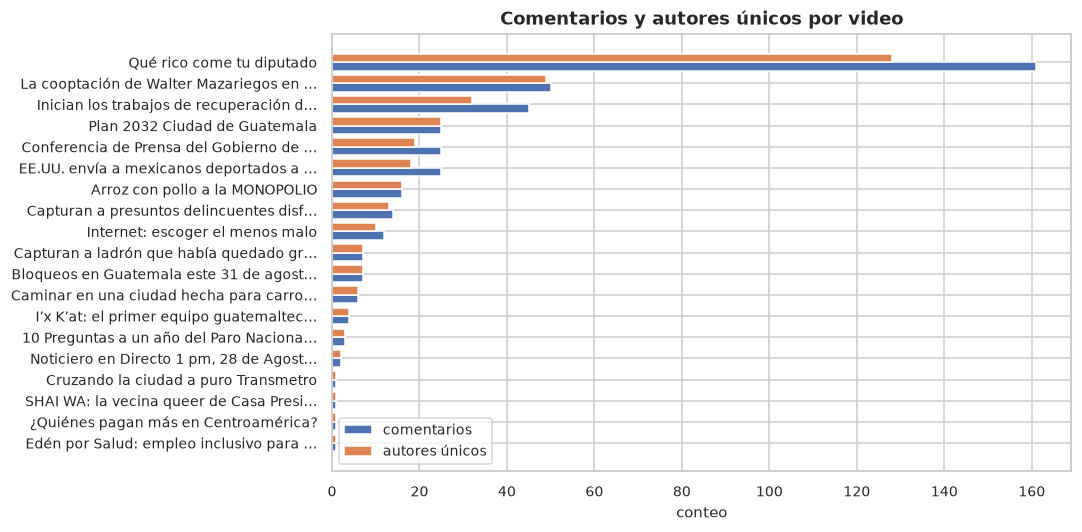

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
orden = por_video.head(19).iloc[::-1]
etiquetas = [f"{t[:38]}…" if len(t) > 38 else t for t in orden["titulo"]]
y = np.arange(len(orden))
ax.barh(y - 0.2, orden["comentarios"], height=0.4, label="comentarios", color="#4C72B0")
ax.barh(y + 0.2, orden["autores"], height=0.4, label="autores únicos", color="#DD8452")
ax.set_yticks(y, etiquetas)
ax.set_title("Comentarios y autores únicos por video")
ax.set_xlabel("conteo")
ax.legend()
plt.tight_layout()
plt.show()

Entre los 19 videos con comentarios, la mediana es de **7 comentarios y 7 autores**, pero el
video más comentado reúne 161 comentarios de 128 autores. La media (21.4) queda muy por encima
de la mediana justamente por ese caso.

El detalle más informativo es que las dos barras del gráfico son casi iguales en todos los
videos: **cada video recibe casi tantos autores distintos como comentarios**. La participación no
proviene de unas pocas personas comentando muchas veces.

### Visualizaciones

view_count en los 293 videos del catálogo
count        293.0
mean       60430.1
std       515798.3
min            2.0
25%          215.0
50%         1175.0
75%         7465.0
90%        51318.8
99%       523972.6
max      8190449.0


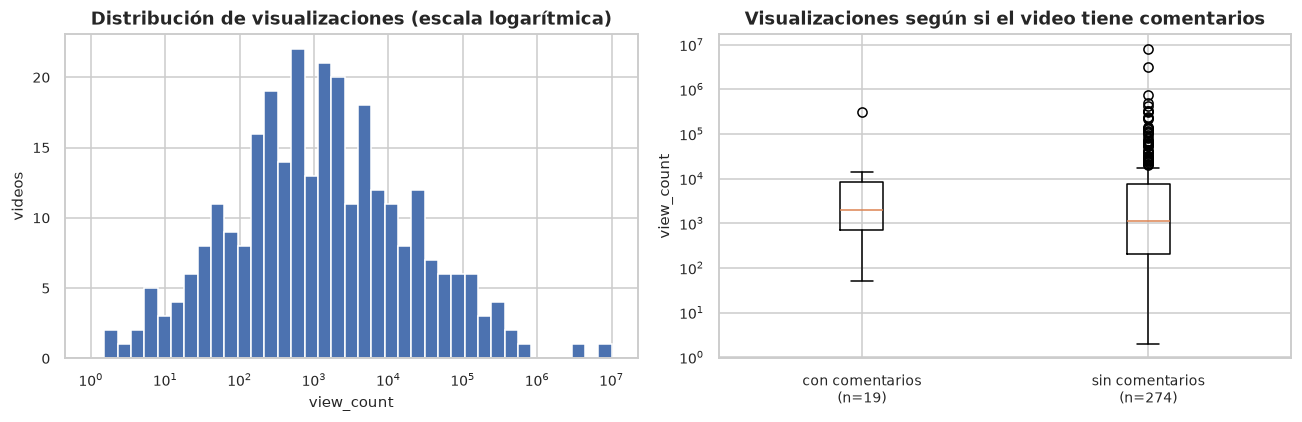


Mediana de visualizaciones -> con comentarios: 1954 | sin comentarios: 1149


In [6]:
print("view_count en los 293 videos del catálogo")
print(videos["view_count"].describe([0.25, 0.5, 0.75, 0.9, 0.99]).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(videos["view_count"], bins=np.logspace(0, 7, 40), color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_title("Distribución de visualizaciones (escala logarítmica)")
axes[0].set_xlabel("view_count")
axes[0].set_ylabel("videos")

datos = [videos.loc[videos["video_id"].isin(cv["video_id"]), "view_count"],
         videos.loc[~videos["video_id"].isin(cv["video_id"]), "view_count"]]
axes[1].boxplot(datos, tick_labels=["con comentarios\n(n=19)", "sin comentarios\n(n=274)"])
axes[1].set_yscale("log")
axes[1].set_title("Visualizaciones según si el video tiene comentarios")
axes[1].set_ylabel("view_count")
plt.tight_layout()
plt.show()

print("\nMediana de visualizaciones -> con comentarios:", int(datos[0].median()),
      "| sin comentarios:", int(datos[1].median()))

Las visualizaciones confirman la cola pesada: la mediana es de **1,175 vistas** mientras la media
es de **60,430**, cincuenta veces mayor, y el máximo llega a 8,190,449. Por eso se grafica en
escala logarítmica y se describe con mediana y cuantiles.

La comparación de la derecha muestra que los 19 videos con comentarios tienen una mediana de
1,954 vistas frente a 1,149 de los 274 sin comentarios. Son ligeramente más vistos, pero **no son
los videos más populares del catálogo**: el conjunto contiene videos con millones de vistas y
ningún comentario recolectado.

### Respuestas y "me gusta"

reply_count (respuestas declaradas por comentario)
count    406.00
mean       0.13
std        0.58
min        0.00
50%        0.00
90%        0.00
99%        3.00
max        7.00
  comentarios sin ninguna respuesta: 376 (92.6%)

like_count ('me gusta' por comentario)
count    406.00
mean       5.73
std       30.66
min        0.00
50%        1.00
90%        7.00
99%      111.30
max      405.00
  comentarios con cero 'me gusta': 189 (46.6%)


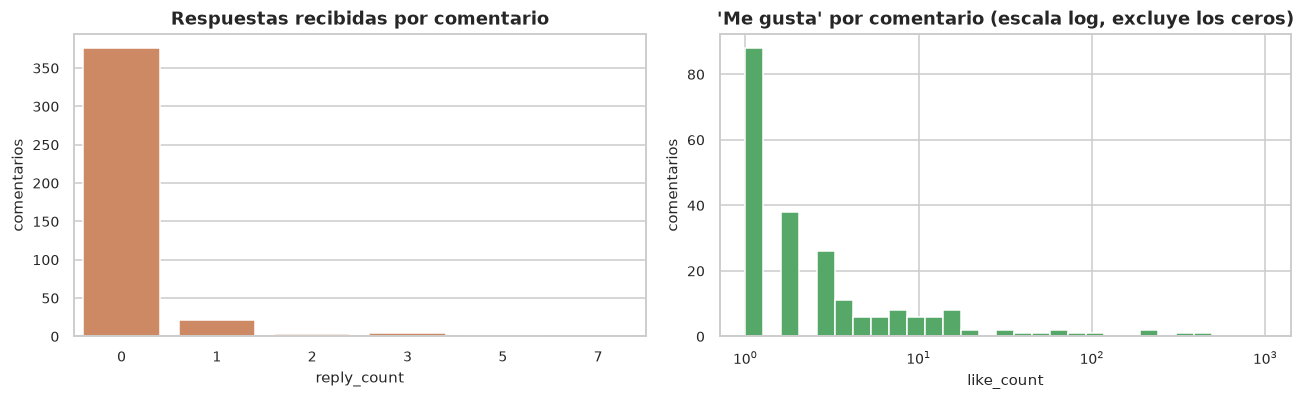

In [7]:
print("reply_count (respuestas declaradas por comentario)")
print(comentarios["reply_count"].describe([0.5, 0.9, 0.99]).round(2).to_string())
print("  comentarios sin ninguna respuesta:", int((comentarios["reply_count"] == 0).sum()),
      f"({(comentarios['reply_count'] == 0).mean():.1%})")
print()
print("like_count ('me gusta' por comentario)")
print(comentarios["like_count"].describe([0.5, 0.9, 0.99]).round(2).to_string())
print("  comentarios con cero 'me gusta':", int((comentarios["like_count"] == 0).sum()),
      f"({(comentarios['like_count'] == 0).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.countplot(x=comentarios["reply_count"], ax=axes[0], color="#DD8452")
axes[0].set_title("Respuestas recibidas por comentario")
axes[0].set_xlabel("reply_count")
axes[0].set_ylabel("comentarios")

axes[1].hist(comentarios["like_count"], bins=np.logspace(0, 3, 30), color="#55A868")
axes[1].set_xscale("log")
axes[1].set_title("'Me gusta' por comentario (escala log, excluye los ceros)")
axes[1].set_xlabel("like_count")
axes[1].set_ylabel("comentarios")
plt.tight_layout()
plt.show()

In [8]:
# Comentarios con más "me gusta"
top_likes = comentarios.nlargest(5, "like_count")[["like_count", "reply_count", "texto_original"]]
top_likes["texto_original"] = top_likes["texto_original"].str.slice(0, 95)
top_likes

,like_count,reply_count,texto_original
299,405,3,Quiero vivir en esa Guatemala :v
193,329,5,Que bueno que Guatemala sea una cuidad bonita ...
338,211,3,Me encantaría vivir por un tiempo en Guatemala...
124,191,2,"Que bella es la Ciudad de Guatemala, unica en ..."
184,113,1,Se ve moderna Y bella la ciudad de Guatemala ....


Las dos formas de reacción son escasas y muy desiguales:

- **Respuestas:** el 92.6% de los comentarios no recibió ninguna; el máximo es 7. Conviene
  recordar que este conteo **no permite saber quién respondió**, así que no genera conexiones.
- **"Me gusta":** el 46.6% tiene cero, la mediana es 1 y el máximo 405.

Los cinco comentarios más gustados son elogios breves hacia la Ciudad de Guatemala, no críticas.
Ese contraste con el vocabulario general de los comentarios se retoma en la Pregunta C.

### Categorías y consultas de búsqueda

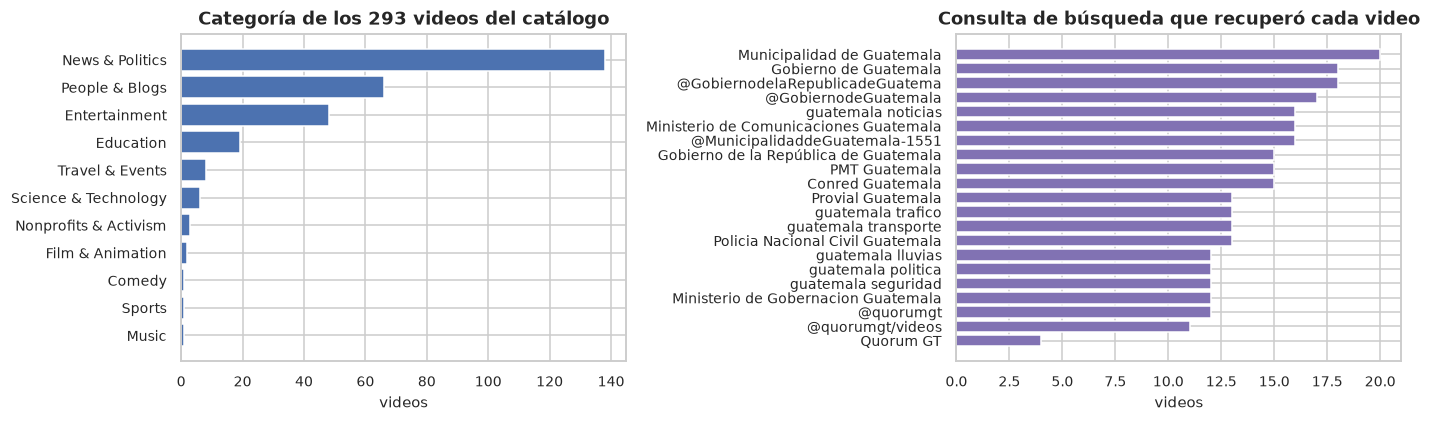

Categoría de los 19 videos que sí tienen comentarios:
categoria
News & Politics          16
Entertainment             2
Nonprofits & Activism     1

Consulta de origen de los 406 comentarios:
source_query_comentario
@quorumgt/videos                         231
guatemala noticias                        55
Gobierno de la República de Guatemala     45
@quorumgt                                 25
Municipalidad de Guatemala                25
@GobiernodeGuatemala                      25


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat = videos["category"].value_counts()
axes[0].barh(cat.index[::-1], cat.values[::-1], color="#4C72B0")
axes[0].set_title("Categoría de los 293 videos del catálogo")
axes[0].set_xlabel("videos")

sq = videos["source_query"].value_counts()
axes[1].barh(sq.index[::-1], sq.values[::-1], color="#8172B3")
axes[1].set_title("Consulta de búsqueda que recuperó cada video")
axes[1].set_xlabel("videos")
plt.tight_layout()
plt.show()

print("Categoría de los 19 videos que sí tienen comentarios:")
print(por_video["categoria"].value_counts().to_string())
print("\nConsulta de origen de los 406 comentarios:")
print(cv["source_query_comentario"].value_counts().to_string())

El catálogo está dominado por **News & Politics (138 de 293 videos)**, seguido de People & Blogs
y Entertainment. La muestra de comentarios es aún más estrecha: de los 19 videos comentados,
**16 son News & Politics** y solo aparecen 3 de las 11 categorías.

Del lado de la recolección, **231 de los 406 comentarios (56.9%) provienen de una sola consulta**,
`@quorumgt/videos`. El contenido observado no es una muestra del habla de YouTube en Guatemala,
sino el resultado de un procedimiento de búsqueda concreto.

### Hashtags

Hashtags en videos (título + descripción): 586 ocurrencias | 337 distintos
Hashtags en comentarios: 1 ocurrencias | 1 distintos -> {'ineptobran': 1}


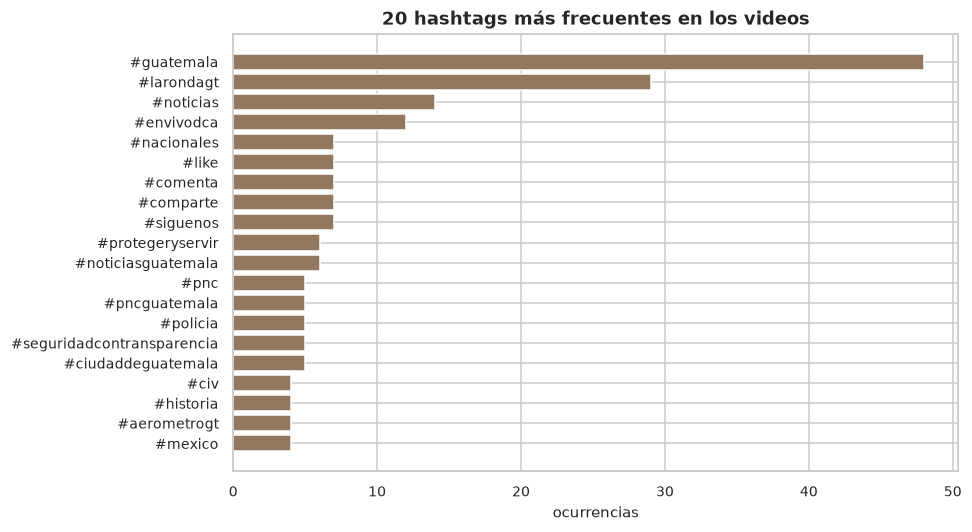

In [10]:
hashtags_videos = Counter(h for lista in videos["hashtags"] for h in lista)
hashtags_com = Counter(h for lista in comentarios["hashtags"] for h in lista)

print("Hashtags en videos (título + descripción):", sum(hashtags_videos.values()),
      "ocurrencias |", len(hashtags_videos), "distintos")
print("Hashtags en comentarios:", sum(hashtags_com.values()),
      "ocurrencias |", len(hashtags_com), "distintos ->", dict(hashtags_com))

top_h = pd.Series(dict(hashtags_videos.most_common(20)))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(["#" + h for h in top_h.index][::-1], top_h.values[::-1], color="#937860")
ax.set_title("20 hashtags más frecuentes en los videos")
ax.set_xlabel("ocurrencias")
plt.tight_layout()
plt.show()

Los hashtags aparecen casi exclusivamente en los videos: **586 ocurrencias de 337 hashtags
distintos**, frente a **uno solo** en los 406 comentarios. En este conjunto el hashtag es un
recurso de quien publica, no de quien comenta.

Los más frecuentes son `#guatemala` (48) y `#larondagt` (29), pero destaca un segundo grupo:
`#like`, `#comenta`, `#comparte` y `#siguenos`, con 7 apariciones cada uno. Estos **no describen
un tema**, sino que son llamados a la acción incluidos en las descripciones. Contar hashtags como
si todos fueran temas sobreestimaría el contenido temático.

### Palabras y bigramas frecuentes

In [11]:
def contar_bigramas(listas_tokens):
    return Counter(
        (t[i], t[i + 1])
        for tokens in listas_tokens
        for t in [list(tokens)]
        for i in range(len(t) - 1)
    )

tokens_com = [list(t) for t in comentarios["tokens"]]
tokens_vid = [list(t) for t in videos["tokens"]]

palabras_com = Counter(t for tokens in tokens_com for t in tokens)
bigramas_com = contar_bigramas(tokens_com)
palabras_vid = Counter(t for tokens in tokens_vid for t in tokens)
bigramas_vid = contar_bigramas(tokens_vid)

print("Comentarios -> tokens totales:", sum(palabras_com.values()),
      "| vocabulario:", len(palabras_com))
print("Videos      -> tokens totales:", sum(palabras_vid.values()),
      "| vocabulario:", len(palabras_vid))

Comentarios -> tokens totales: 3872 | vocabulario: 1879
Videos      -> tokens totales: 9982 | vocabulario: 3307


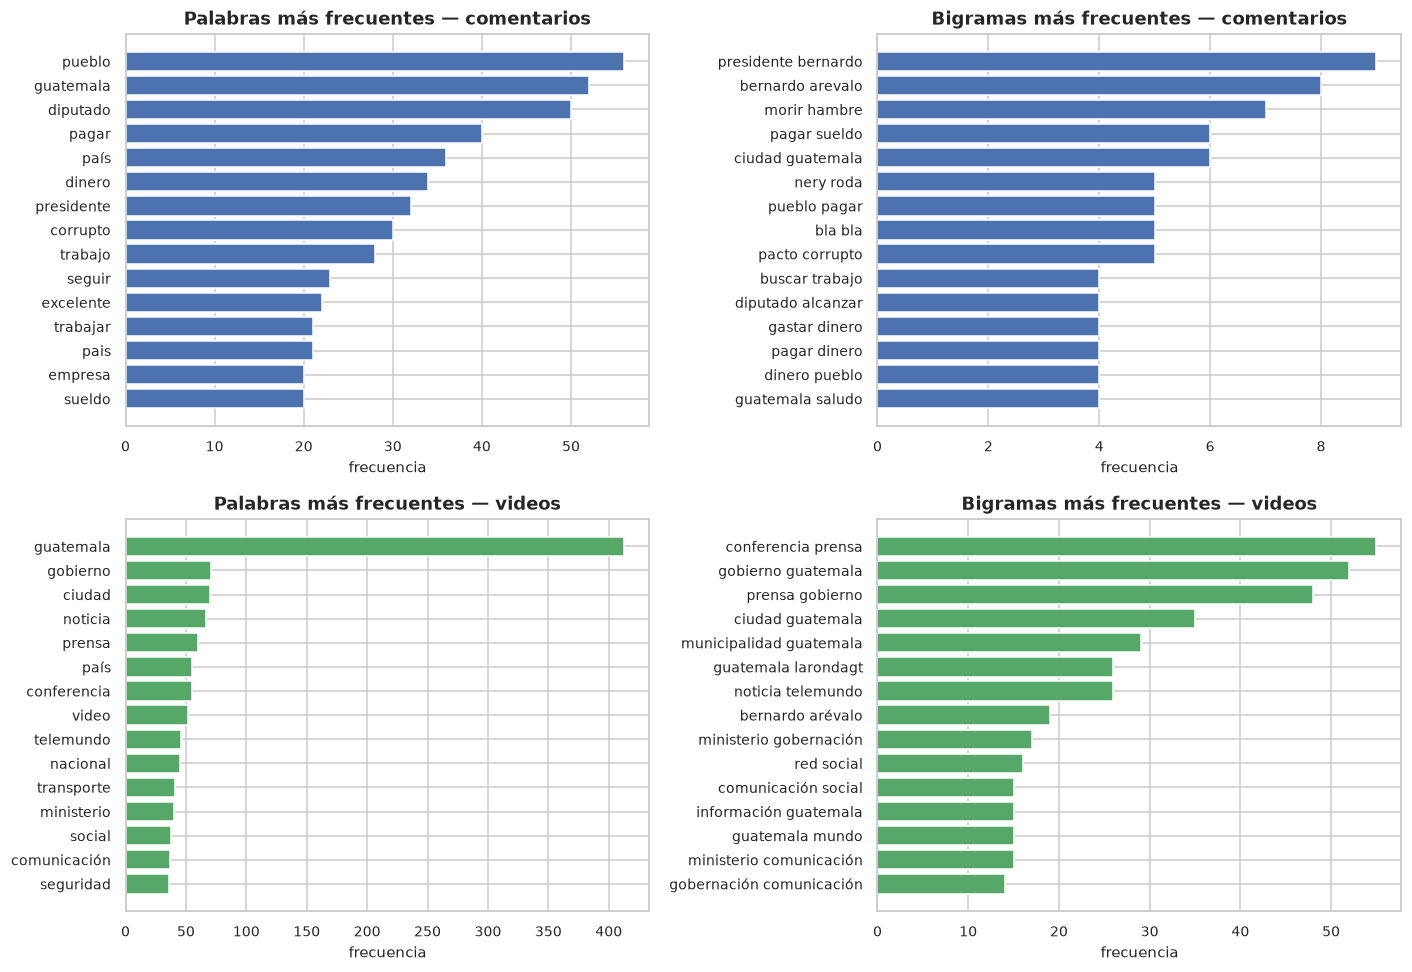

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

def barras(ax, contador, titulo, color, es_bigrama=False):
    top = contador.most_common(15)[::-1]
    etiquetas = [" ".join(k) if es_bigrama else k for k, _ in top]
    ax.barh(etiquetas, [v for _, v in top], color=color)
    ax.set_title(titulo)
    ax.set_xlabel("frecuencia")

barras(axes[0, 0], palabras_com, "Palabras más frecuentes — comentarios", "#4C72B0")
barras(axes[0, 1], bigramas_com, "Bigramas más frecuentes — comentarios", "#4C72B0", True)
barras(axes[1, 0], palabras_vid, "Palabras más frecuentes — videos", "#55A868")
barras(axes[1, 1], bigramas_vid, "Bigramas más frecuentes — videos", "#55A868", True)
plt.tight_layout()
plt.show()

La comparación entre los dos corpus es el hallazgo más claro de esta sección:

- **Videos** (lenguaje de quien publica): *guatemala* (413), *gobierno*, *ciudad*, *noticia*,
  *prensa*. Los bigramas son institucionales y descriptivos: *conferencia prensa* (55),
  *gobierno guatemala* (52), *municipalidad guatemala* (29).
- **Comentarios** (lenguaje de quien participa): *pueblo* (56), *guatemala* (52), *diputado* (50),
  *pagar* (40), *dinero* (34), *corrupto* (30). Los bigramas son evaluativos:
  *presidente bernardo* (9), *morir hambre* (7), *pagar sueldo* (6), *pacto corrupto* (5).

Quien publica **informa**; quien comenta **opina y reclama**, con un vocabulario centrado en
dinero público, sueldos de diputados y corrupción. Esta observación es descriptiva: mide qué
palabras aparecen, no la intención de quien las escribió.

## 3.2 Concentración de la participación

Para medir qué tan desigual es el reparto de los comentarios se usan dos herramientas: el
**porcentaje acumulado** que aportan los elementos más activos y el **coeficiente de Gini**, que
resume la desigualdad en un número entre 0 (reparto perfectamente igual) y 1 (todo concentrado en
un solo elemento).

In [13]:
def gini(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    indice = np.arange(1, n + 1)
    return float((2 * indice - n - 1).dot(x) / (n * x.sum()))


def concentracion(serie, nombre):
    s = serie.sort_values(ascending=False)
    total = s.sum()
    fila = {"agrupación": nombre, "n_elementos": len(s), "total_comentarios": int(total),
            "Gini": round(gini(s.values), 3)}
    for k in [1, 3, 5, 10]:
        if k <= len(s):
            fila[f"% en top-{k}"] = round(s.head(k).sum() / total * 100, 1)
    return fila


com_por_video = cv.groupby("video_id").size()
com_por_canal = cv.groupby("channel_id").size()
com_por_autor = cv.groupby("author_channel_id").size()

pd.DataFrame([
    concentracion(com_por_video, "videos con comentarios"),
    concentracion(com_por_canal, "canales con comentarios"),
    concentracion(com_por_autor, "autores"),
])

,agrupación,n_elementos,total_comentarios,Gini,% en top-1,% en top-3,% en top-5,% en top-10
0,videos con comentarios,19,406,0.660,39.7,63.1,75.4,93.6
1,canales con comentarios,8,406,0.664,63.1,86.5,96.1,NaN
2,autores,332,406,0.164,1.5,4.2,6.4,10.3


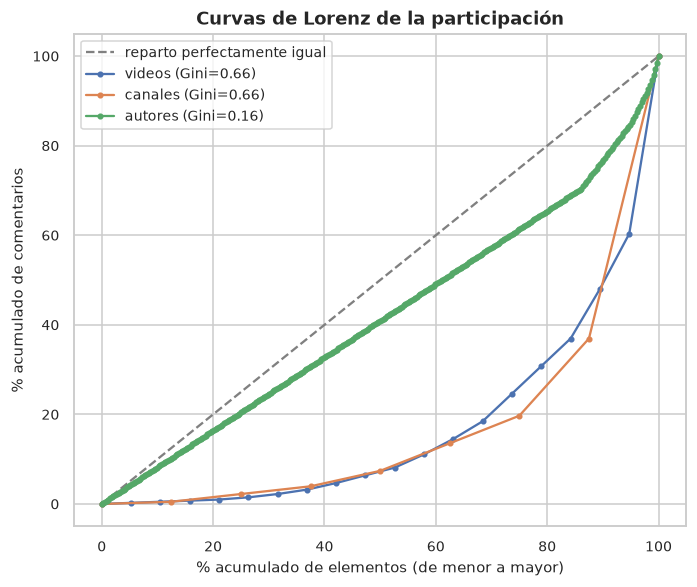

In [14]:
def lorenz(ax, valores, etiqueta, color):
    x = np.sort(np.asarray(valores, dtype=float))
    acum = np.concatenate([[0], np.cumsum(x) / x.sum()])
    prop = np.linspace(0, 1, len(acum))
    ax.plot(prop * 100, acum * 100, marker="o", ms=3, label=f"{etiqueta} (Gini={gini(x):.2f})", color=color)


fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 100], [0, 100], "--", color="gray", label="reparto perfectamente igual")
lorenz(ax, com_por_video, "videos", "#4C72B0")
lorenz(ax, com_por_canal, "canales", "#DD8452")
lorenz(ax, com_por_autor, "autores", "#55A868")
ax.set_title("Curvas de Lorenz de la participación")
ax.set_xlabel("% acumulado de elementos (de menor a mayor)")
ax.set_ylabel("% acumulado de comentarios")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
# Recurrencia de los autores
recurrencia = com_por_autor.value_counts().sort_index()
print("Autores según el número de comentarios que escribieron")
print(recurrencia.rename_axis("comentarios_escritos").to_frame("autores").to_string())
print("\nAutores con un solo comentario:", int(recurrencia.get(1, 0)),
      f"({recurrencia.get(1, 0) / com_por_autor.size:.1%})")

Autores según el número de comentarios que escribieron
                      autores
comentarios_escritos         
1                         286
2                          30
3                          10
4                           2
5                           2
6                           2

Autores con un solo comentario: 286 (86.1%)


**La concentración está en los videos y los canales, no en los autores.**

| Agrupación | Gini | Lectura |
| --- | --- | --- |
| Videos (19) | **0.660** | Un solo video acumula el 39.7% de los comentarios; el top-3 llega al 63.1% y el top-10 al 93.6% |
| Canales (8) | **0.664** | Un solo canal acumula el 63.1%; el top-3 llega al 86.5% |
| Autores (332) | **0.164** | El top-10 de autores apenas suma el 10.3% |

Las curvas de Lorenz muestran lo mismo: las de videos y canales se despegan mucho de la diagonal,
mientras la de autores casi la sigue.

La razón se ve en la tabla de recurrencia: **286 de los 332 autores (86.1%) escribieron un solo
comentario**, y el más activo escribió apenas 6. No existen participantes hiperactivos. Lo que
concentra la participación es **dónde ocurre** (unos pocos videos de unos pocos canales), no
**quién la produce**.

Debe recordarse que esta concentración se mide sobre datos ya sesgados: los 19 videos con
comentarios fueron los que quedaron cubiertos por la recolección.

## 3.3 Popularidad frente a participación

Correlación de Spearman sobre los 19 videos con comentarios
  visualizaciones vs comentarios     -> rho = 0.811 (p = 0.00002)
  visualizaciones vs autores únicos  -> rho = 0.812 (p = 0.00002)


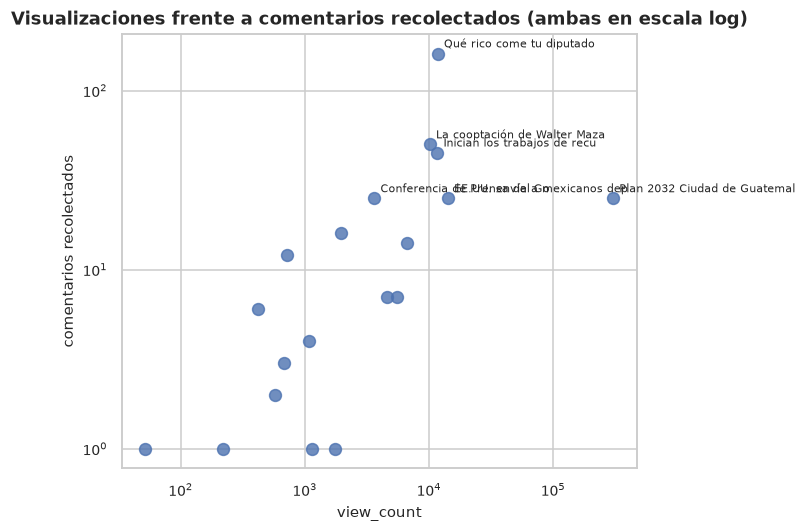

In [16]:
rho_com, p_com = spearmanr(por_video["vistas"], por_video["comentarios"])
rho_aut, p_aut = spearmanr(por_video["vistas"], por_video["autores"])

print(f"Correlación de Spearman sobre los {len(por_video)} videos con comentarios")
print(f"  visualizaciones vs comentarios     -> rho = {rho_com:.3f} (p = {p_com:.5f})")
print(f"  visualizaciones vs autores únicos  -> rho = {rho_aut:.3f} (p = {p_aut:.5f})")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(por_video["vistas"], por_video["comentarios"], s=60, alpha=0.8, color="#4C72B0")
for vid, fila in por_video.iterrows():
    if fila["comentarios"] >= 25 or fila["vistas"] > 100_000:
        ax.annotate(fila["titulo"][:28], (fila["vistas"], fila["comentarios"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Visualizaciones frente a comentarios recolectados (ambas en escala log)")
ax.set_xlabel("view_count")
ax.set_ylabel("comentarios recolectados")
plt.tight_layout()
plt.show()

La correlación de Spearman entre visualizaciones y comentarios es **alta y significativa**
(rho = 0.811, p = 0.00002), y prácticamente la misma con el número de autores únicos
(rho = 0.812). En estos 19 videos, más visibilidad viene acompañada de más participación.

Ese resultado, sin embargo, tiene **tres limitaciones fuertes** que impiden generalizarlo:

1. **Solo 19 puntos**, y no elegidos al azar: son precisamente los videos para los que se
   recolectaron comentarios. Los 274 videos restantes, algunos con millones de vistas, no
   participan del cálculo.
2. **El conteo de comentarios mide recolección, no participación real.** En el gráfico se ve que
   tres videos distintos tienen exactamente 25 comentarios, lo que sugiere un tope en el proceso
   de extracción. Si existe ese tope, la participación de los videos más comentados está
   truncada hacia abajo.
3. **Los dos conteos no son comparables en el tiempo.** `view_count` acumula desde la
   publicación, mientras que los comentarios recolectados son solo los que estaban visibles en
   ese momento, y los videos tienen antigüedades distintas.

Las excepciones lo ilustran: *Plan 2032 Ciudad de Guatemala* tiene 304,089 vistas y 25
comentarios, mientras que *Qué rico come tu diputado* tiene 11,775 vistas y 161 comentarios. La
asociación existe, pero **no es una relación causal ni una regla fiable**.

## 3.4 Nube de palabras

La nube de palabras se incluye como complemento visual. **No sustituye** a los gráficos de
frecuencia de la sección 3.1: permite ver el vocabulario de un vistazo, pero no permite comparar
magnitudes con precisión.

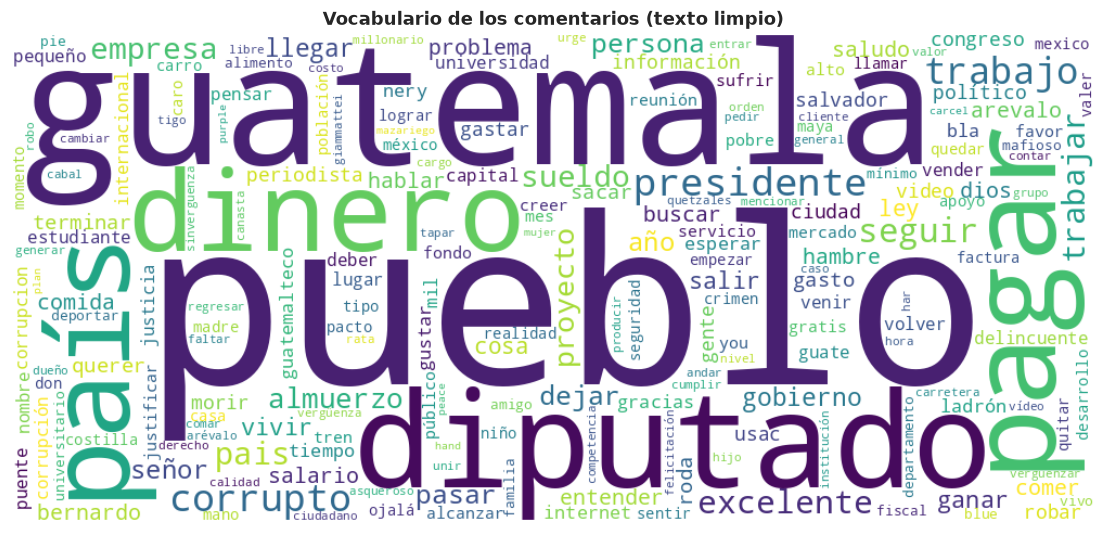

In [17]:
nube = WordCloud(width=1000, height=450, background_color="white",
                 colormap="viridis", random_state=42).generate_from_frequencies(palabras_com)

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(nube, interpolation="bilinear")
ax.axis("off")
ax.set_title("Vocabulario de los comentarios (texto limpio)")
plt.tight_layout()
plt.show()

## 3.5 Preguntas obligatorias

Antes de responder se calcula la **co-ocurrencia autor–video**: qué autores participaron en más
de un video, en más de un canal o en más de una categoría. Es la evidencia que sostiene las
preguntas sobre audiencias compartidas y autores puente, y es el precursor directo de la red
bipartita del Ejercicio 4.

In [18]:
perfil_autor = cv.groupby("author_channel_id").agg(
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    canales=("channel_id", "nunique"),
    categorias=("category", "nunique"),
).sort_values(["videos", "comentarios"], ascending=False)

print("Autores totales:", len(perfil_autor))
print("  con más de un comentario:", int((perfil_autor["comentarios"] > 1).sum()),
      f"({(perfil_autor['comentarios'] > 1).mean():.1%})")
print("  que comentaron en más de un VIDEO:", int((perfil_autor["videos"] > 1).sum()),
      f"({(perfil_autor['videos'] > 1).mean():.1%})")
print("  que comentaron en más de un CANAL:", int((perfil_autor["canales"] > 1).sum()))
print("  que comentaron en más de una CATEGORÍA:", int((perfil_autor["categorias"] > 1).sum()))

perfil_autor[perfil_autor["videos"] > 1]

Autores totales: 332
  con más de un comentario: 46 (13.9%)
  que comentaron en más de un VIDEO: 9 (2.7%)
  que comentaron en más de un CANAL: 4
  que comentaron en más de una CATEGORÍA: 2


,comentarios,videos,canales,categorias
author_channel_id,,,,
UCvcu1kR8xMYy_I1Ty-2mV2Q,4,3,1,1
UCpsKOkt5iWTbenzeuq7dsmQ,3,3,1,1
UCHTGCgY2l-DQJIvlA_cpa_Q,3,2,2,2
UCylqlpsh8ENNM1LqgQ1KbxA,3,2,1,1
UCbrtvygfRT6QXqWDNrOf-cA,2,2,1,1
UCdFlugHJJa4l3YqWuNRmvXw,2,2,2,1
UCjZgFEowMBrsjodqfovzdKw,2,2,2,2
UCsUCN0Yq_UyTvKjOJLmNrnQ,2,2,2,1
UCzZ6dDCEsLMXbc5pCFXIprw,2,2,1,1


In [19]:
# Pares de videos que comparten al menos un autor: base de la proyección video-video del Ej. 5
pares = {}
for autor, grupo in cv.groupby("author_channel_id")["video_id"]:
    vids = sorted(set(grupo))
    for i in range(len(vids)):
        for j in range(i + 1, len(vids)):
            pares[(vids[i], vids[j])] = pares.get((vids[i], vids[j]), 0) + 1

titulo = por_video["titulo"].to_dict()
canal = por_video["canal"].to_dict()
tabla_pares = pd.DataFrame([
    {"video_A": titulo[a][:34], "video_B": titulo[b][:34],
     "canal_A": canal[a], "canal_B": canal[b], "autores_compartidos": n}
    for (a, b), n in sorted(pares.items(), key=lambda x: -x[1])
])
print("Pares de videos que comparten al menos un autor:", len(tabla_pares),
      "de", len(por_video) * (len(por_video) - 1) // 2, "pares posibles")
tabla_pares

Pares de videos que comparten al menos un autor: 11 de 171 pares posibles


,video_A,video_B,canal_A,canal_B,autores_compartidos
0,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO,Quorum,Quorum,2
1,La cooptación de Walter Mazariegos,Qué rico come tu diputado,Quorum,Quorum,2
2,Conferencia de Prensa del Gobierno,Qué rico come tu diputado,Gobierno de la República de Guatemala,Quorum,1
3,Capturan a ladrón que había quedad,La cooptación de Walter Mazariegos,TN23 Guatemala,Quorum,1
4,Capturan a presuntos delincuentes,Inician los trabajos de recuperaci,Noti7,Gobierno de la República de Guatemala,1
5,La cooptación de Walter Mazariegos,Internet: escoger el menos malo,Quorum,Quorum,1
6,Qué rico come tu diputado,Internet: escoger el menos malo,Quorum,Quorum,1
7,Bloqueos en Guatemala este 31 de a,Qué rico come tu diputado,PrensaLibreOficial,Quorum,1
8,Caminar en una ciudad hecha para c,Internet: escoger el menos malo,Quorum,Quorum,1
9,Caminar en una ciudad hecha para c,Arroz con pollo a la MONOPOLIO,Quorum,Quorum,1


In [20]:
# Temas dominantes en los canales con más participación
top3_canales = com_por_canal.sort_values(ascending=False).head(3).index
for cid in top3_canales:
    sub = cv[cv["channel_id"] == cid]
    tokens = Counter(t for lista in sub["tokens_comentario"] for t in lista)
    print(f"{sub['channel_name'].iat[0]}  ({len(sub)} comentarios, "
          f"{sub['video_id'].nunique()} videos, {sub['author_channel_id'].nunique()} autores)")
    print("   palabras más frecuentes:", ", ".join(p for p, _ in tokens.most_common(12)))
    print()

Quorum  (256 comentarios, 11 videos, 214 autores)
   palabras más frecuentes: pueblo, diputado, pagar, dinero, corrupto, trabajo, sueldo, empresa, excelente, almuerzo, seguir, trabajar

Gobierno de la República de Guatemala  (70 comentarios, 2 videos, 50 autores)
   palabras más frecuentes: presidente, guatemala, país, año, arevalo, terminar, proyecto, bernardo, gobierno, puente, pais, salvador

Noticias Telemundo  (25 comentarios, 1 videos, 18 autores)
   palabras más frecuentes: you, país, deportar, entrar, pais, persona, pasar, mexicano, méxico, regresar, and, don



### Respuestas

**¿Qué videos y canales concentran la mayor participación observada?**
El video **"Qué rico come tu diputado"** (canal *Quorum*) concentra 161 comentarios de 128
autores, el 39.7% de todos los comentarios. El canal **Quorum** reúne 256 comentarios (63.1%)
repartidos en 11 videos y 214 autores. Le siguen *Gobierno de la República de Guatemala* (70
comentarios) y *Noticias Telemundo* (25).

**¿Existen audiencias compartidas entre videos, canales o temas?**
Muy pocas. Solo **9 de los 332 autores (2.7%) comentaron en más de un video**, 4 en más de un
canal y 2 en más de una categoría. De los 171 pares de videos posibles, **únicamente 11 comparten
algún autor**, y en 9 de esos 11 casos comparten un solo autor. La mayor parte de los enlaces
ocurre **dentro** del canal Quorum. Esto anticipa que la proyección autor–autor del Ejercicio 5
será una red muy fragmentada.

**¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?**
Los candidatos son los 4 autores que comentaron en más de un canal, y en particular los 2 que
además cruzan categorías: `UCHTGCgY2l-DQJIvlA_cpa_Q` (3 comentarios en 2 videos, 2 canales, 2
categorías) y `UCjZgFEowMBrsjodqfovzdKw` (2 comentarios en 2 videos, 2 canales, 2 categorías).
Son puentes **en el sentido estructural**: sin ellos, esos canales quedarían desconectados en la
red. La medición formal con centralidad de intermediación se realiza en el **Ejercicio 8**.

**¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?**
Tomando los tres canales más comentados como grupos observables, los temas son claramente
distintos:

| Canal | Participación | Vocabulario dominante |
| --- | --- | --- |
| Quorum | 256 comentarios, 11 videos, 214 autores | *pueblo, diputado, pagar, dinero, corrupto, sueldo* — gasto público y clase política |
| Gobierno de la República | 70 comentarios, 2 videos, 50 autores | *presidente, guatemala, país, arévalo, proyecto, puente* — obra pública y figura presidencial |
| Noticias Telemundo | 25 comentarios, 1 video, 18 autores | *deportar, entrar, mexicano, méxico, regresar* — migración y deportaciones |

La parte de **sentimiento** requiere una herramienta específica para español y se desarrolla en el
**Ejercicio 9**; la caracterización por comunidad detectada algorítmicamente, en el **Ejercicio 7**.

**¿La visibilidad medida mediante visualizaciones coincide con la participación observada?**
Coincide de forma general (rho = 0.811) pero **no de forma fiable**, según lo discutido en 3.3:
hay videos muy vistos con poca participación recolectada y viceversa, y existe evidencia de un
tope en la extracción.

**¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura?**
Prácticamente todas las que involucran participación:

- Solo el **6.5% de los videos** tiene comentarios, así que la red describe 19 videos, no 293.
- El **56.9% de los comentarios** proviene de una sola consulta (`@quorumgt/videos`), lo que
  explica por sí solo el dominio del canal Quorum.
- Los **105 videos de canales oficiales de gobierno** (`source_group = official_gov`) no
  aportaron ningún comentario.
- Los tiempos son **relativos** y los conteos son **instantáneas**, así que no se puede analizar
  evolución temporal.
- La baja co-participación entre autores puede reflejar la cobertura parcial y no un
  comportamiento real de las audiencias.

## 3.6 Preguntas adicionales

Las tres preguntas siguientes surgieron al observar los resultados anteriores.

### Pregunta A. ¿La muestra de comentarios es representativa del catálogo de videos?

In [21]:
videos["tiene_comentarios"] = videos["video_id"].isin(cv["video_id"])
comparacion = videos.groupby("tiene_comentarios").agg(
    videos=("video_id", "size"),
    canales=("channel_id", "nunique"),
    vistas_medianas=("view_count", "median"),
    categorias=("category", "nunique"),
)
print(comparacion.to_string())
print("\nsource_group de los videos, según si tienen comentarios:")
print(pd.crosstab(videos["source_group"], videos["tiene_comentarios"]).to_string())
print("\nProporción del catálogo que aporta el canal más comentado:")
cid_top = com_por_canal.idxmax()
print("  canal:", videos.loc[videos["channel_id"] == cid_top, "channel_name"].iat[0])
print("  videos suyos en el catálogo:", int((videos["channel_id"] == cid_top).sum()), "de 293")
print("  comentarios suyos en la muestra:", int(com_por_canal.max()), "de 406")

                   videos  canales  vistas_medianas  categorias
tiene_comentarios                                              
False                 274       97           1149.5          11
True                   19        8           1954.0           3

source_group de los videos, según si tienen comentarios:
tiene_comentarios  False  True 
source_group                   
channel                4      7
official_gov         105      0
topic                165     12

Proporción del catálogo que aporta el canal más comentado:
  canal: Quorum
  videos suyos en el catálogo: 18 de 293
  comentarios suyos en la muestra: 256 de 406


**Respuesta.** No lo es, y la diferencia es grande:

| | Con comentarios | Sin comentarios |
| --- | --- | --- |
| Videos | 19 | 274 |
| Canales | 8 | 97 |
| Categorías representadas | 3 | 11 |
| Mediana de visualizaciones | 1,954 | 1,149 |

El sesgo se ve mejor por `source_group`: **los 105 videos de canales oficiales de gobierno no
tienen ni un solo comentario recolectado**, mientras que 7 de los 11 videos hallados por canal sí
los tienen. Y el canal *Quorum*, que aporta **18 de los 293 videos (6.1%) del catálogo, produce
256 de los 406 comentarios (63.1%)**.

La conclusión metodológica es directa: la muestra de comentarios **no representa al catálogo**.
Cualquier afirmación sobre "los canales guatemaltecos" basada en estos comentarios estaría
describiendo, en realidad, a un canal.

### Pregunta B. ¿La participación en un video viene de más gente o de la misma gente comentando más?

Razón comentarios / autores únicos por video
count    19.00
mean      1.09
std       0.15
min       1.00
25%       1.00
50%       1.00
75%       1.14
max       1.41

                                             canal  comentarios  autores  com_por_autor
video_id                                                                               
n8iP75gIpmw                                 Quorum          161      128           1.26
j43HgwYFKfk                                 Quorum           50       49           1.02
6W4u8sGEnGM  Gobierno de la República de Guatemala           45       32           1.41
lj983NWyAQY             Municipalidad de Guatemala           25       25           1.00
PjmxCj-a9Hg  Gobierno de la República de Guatemala           25       19           1.32
OkXlHx0hx-8                     Noticias Telemundo           25       18           1.39
yLZS3JiEBg8                                 Quorum           16       16           1.00
06mFNPU0aB8                               

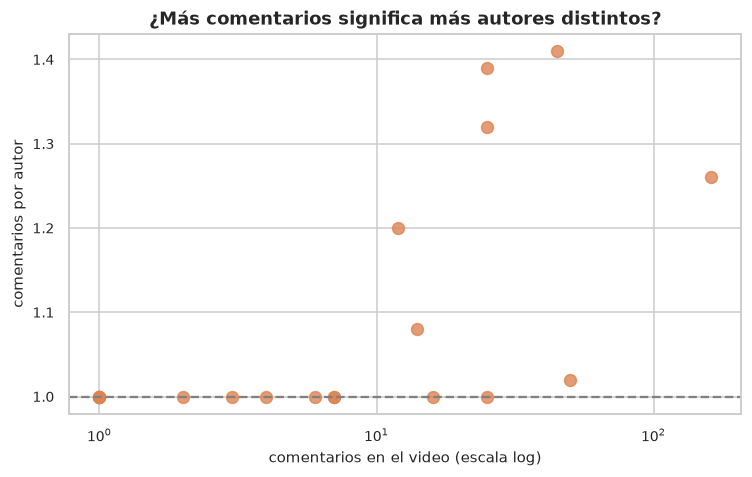

In [22]:
print("Razón comentarios / autores únicos por video")
print(por_video["com_por_autor"].describe().round(2).to_string())
print()
print(por_video[["canal", "comentarios", "autores", "com_por_autor"]].head(8).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(por_video["comentarios"], por_video["com_por_autor"], s=60, alpha=0.8, color="#DD8452")
ax.axhline(1, ls="--", color="gray")
ax.set_xscale("log")
ax.set_title("¿Más comentarios significa más autores distintos?")
ax.set_xlabel("comentarios en el video (escala log)")
ax.set_ylabel("comentarios por autor")
plt.tight_layout()
plt.show()

**Respuesta.** Viene de gente nueva. La razón entre comentarios y autores únicos tiene **mediana
1.00 y media 1.09**, con un máximo de 1.41. Ni siquiera el video con 161 comentarios se aleja
mucho: reúne 128 autores distintos, una razón de 1.26.

Combinado con el hallazgo de la sección 3.2 (86.1% de los autores escribió un solo comentario),
el patrón es consistente: **la participación observada es amplia y superficial, no profunda y
repetida**. No hay indicios de cuentas que comenten sistemáticamente en muchos videos, que es la
señal estructural que buscaría un análisis de coordinación.

Este resultado también está condicionado por la cobertura: si la recolección tomó los primeros
comentarios de cada video, los participantes recurrentes podrían simplemente no haber sido
capturados.

### Pregunta C. ¿Los comentarios que reciben más "me gusta" se distinguen de los demás?

In [23]:
comentarios["n_tokens"] = comentarios["tokens"].map(len)
comentarios["grupo_likes"] = np.where(comentarios["like_count"] >= 5, "5 o más 'me gusta'", "menos de 5")

resumen_likes = comentarios.groupby("grupo_likes").agg(
    comentarios=("comment_id", "size"),
    tokens_mediana=("n_tokens", "median"),
    caracteres_mediana=("texto_original", lambda s: s.str.len().median()),
    respuestas_totales=("reply_count", "sum"),
)
print(resumen_likes.to_string())
print()
for grupo in ["5 o más 'me gusta'", "menos de 5"]:
    sub = comentarios[comentarios["grupo_likes"] == grupo]
    tokens = Counter(t for lista in sub["tokens"] for t in lista)
    print(f"{grupo}: ", ", ".join(p for p, _ in tokens.most_common(10)))

                    comentarios  tokens_mediana  caracteres_mediana  respuestas_totales
grupo_likes                                                                            
5 o más 'me gusta'           54             6.5                85.5                  26
menos de 5                  352             7.0                98.5                  25

5 o más 'me gusta':  guatemala, pueblo, diputado, sueldo, ciudad, saludo, vivir, pagar, trabajo, presidente
menos de 5:  pueblo, diputado, pagar, guatemala, dinero, país, presidente, corrupto, trabajo, excelente


**Respuesta.** Sí, se distinguen en dos aspectos:

1. **Son más cortos.** Los 54 comentarios con 5 o más "me gusta" tienen una mediana de 85.5
   caracteres frente a 98.5 del resto.
2. **Su vocabulario es distinto.** Los muy gustados hablan de *guatemala, ciudad, saludo, vivir*;
   el resto habla de *dinero, corrupto, país*. Es decir, **los comentarios elogiosos y breves
   reciben más "me gusta" que los críticos**, aunque estos últimos sean mayoría.

Un tercer dato llama la atención: esos 54 comentarios acumulan **26 respuestas**, prácticamente
las mismas (25) que los 352 restantes. La atención, igual que la participación, se concentra.

Debe subrayarse que esto es una **asociación descriptiva**: los datos no permiten afirmar que ser
elogioso *cause* más "me gusta". Los comentarios más gustados también podrían ser simplemente los
más antiguos o los mejor posicionados en el orden de visualización de YouTube, información que el
conjunto no contiene.

---

## Resumen del notebook

El análisis exploratorio dejó cuatro hallazgos principales:

1. **La cobertura es el factor dominante.** Solo 19 de 293 videos y 8 de 97 canales tienen
   comentarios, y el 56.9% de estos proviene de una sola consulta de búsqueda.
2. **La concentración está en el contenido, no en las personas.** Los videos y canales tienen un
   Gini cercano a 0.66, mientras los autores apenas llegan a 0.164. El 86.1% de los autores
   escribió un único comentario.
3. **Publicar y comentar usan lenguajes distintos.** Los videos hablan en términos
   institucionales (*conferencia prensa*, *gobierno guatemala*); los comentarios, en términos de
   dinero público y crítica política (*pueblo*, *diputado*, *corrupto*, *pagar sueldo*).
4. **La co-participación entre autores es mínima.** Solo 9 autores comentaron en más de un video
   y apenas 11 pares de videos comparten alguien. La red bipartita del Ejercicio 4 será, por lo
   tanto, muy fragmentada, y conviene anticiparlo antes de calcular métricas globales.

Estos resultados definen el punto de partida del **Notebook 3**, dedicado a la construcción de la
red bipartita autor–video y sus proyecciones.